<a href="https://colab.research.google.com/github/mgb1112/Data-Science-For-Public-Health/blob/main/hw9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authors:
Zhenlong Zhang,
Grace Brooks,
Mingrui Xu,
Rosie Quint,
Liesel Arauz Vallecillo

**Homework 9**

The goal of this HW is simple. Duplicate (repeat all parts of) homework 8 problem 2 using neural networks. Perform an appropriate contrast of your regression results versus using i.) a neural network with 2 hidden nodes and ii.) 4 hidden nodes over 2 layers with 2 hidden nodes in each layer. All layers should be full connectected, MSE the loss function, a linear output activation layer and RELUs otherwise.

You should return an ipynb nothebook with your code and a final table contrasting the different error rates of the different approaches you tried.

*Homework 8 Directions*

1. Get the country-specific covid case data from here. (Note pandas allows you to load a csv file from a URL. Make sure to use the "raw" link to the file on github.). Pick a country. Let  Yt  be the new (incident) case count for day  t  since the outbreak onset for that country. That is, process the time series so that  t=0  is the first day with more than 0 cases. Then, fit a distributed lag linear model as follows.
Yt=α0+β1Yt−1+β2Yt−2+…+βkYt−5+ϵt
That is, see how the last five days predicts the current day. Report and interpret the coefficients.
2. Refer to the previous question. Let A and B be your two countries. Create a plot of time versus prediction error for the following: a. fit the model on (all of) A and apply it to (all of) A to get the mean squared error, b. fit A on the first half of the time for A, apply it to the second half of A to get the mean squared error.

# Preparation code (from HW8)

In [ ]:
# HW 8 code
import pandas as pd
import statsmodels.api as sm
import numpy as np
import torch as torch

# Load the data
data_url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
df = pd.read_csv(data_url)

# Choose a country ('US')
country = 'US'
df_country = df[df['Country/Region'] == country]

df_country = df_country.drop(columns=['Lat', 'Long'])

# Sum cases across different provinces/states for the US
df_country = df_country.sum(numeric_only=True, axis=0)

# print(df_country)

# Convert the series to a DataFrame and reset the index
df_country = pd.DataFrame(df_country).reset_index()
df_country.columns = ['Date', 'Cases']

# Convert from Cumulative to Daily Cases
covid_data_daily = df_country['Cases'].diff()
df_country['Daily'] = covid_data_daily

# Reset the index to represent days since the outbreak onset (t=0)
df_country = df_country.reset_index(drop=True)

# Create lagged variables (up to 5 days) -- note the lagged case variables refer to daily case counts
for i in range(1, 6):
    df_country[f'Cases_lag{i}'] = df_country['Daily'].shift(i)

# Drop rows with NaN values caused by lagging
df_country = df_country.dropna()
df_country.head()

# Define dependent and independent variables
y = df_country['Daily']
X = df_country[['Cases_lag1', 'Cases_lag2', 'Cases_lag3', 'Cases_lag4', 'Cases_lag5']]
X = sm.add_constant(X)  # Add a constant term

# HW 9 code

In [ ]:
# just for downloading the packages used
!pip install pandas numpy matplotlib scikit-learn statsmodels torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 813.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 25.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import matplotlib.pyplot as plt

,Model,MSE (Full Fit),MSE (Half Split)
0,Linear Regression,4.217760e+09,7.835678e+09
1,"NN (1 layer, 2 nodes)",2.496797e+10,4.068589e+10
2,"NN (2 layers, 2+2 nodes)",2.472324e+10,4.028429e+10


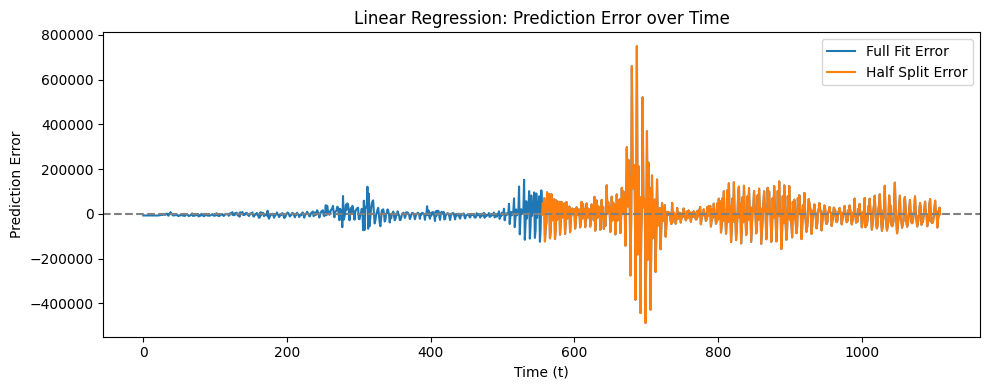

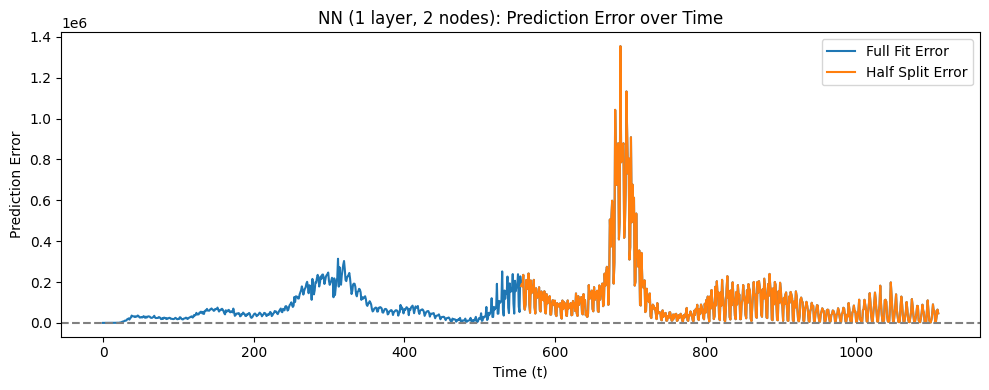

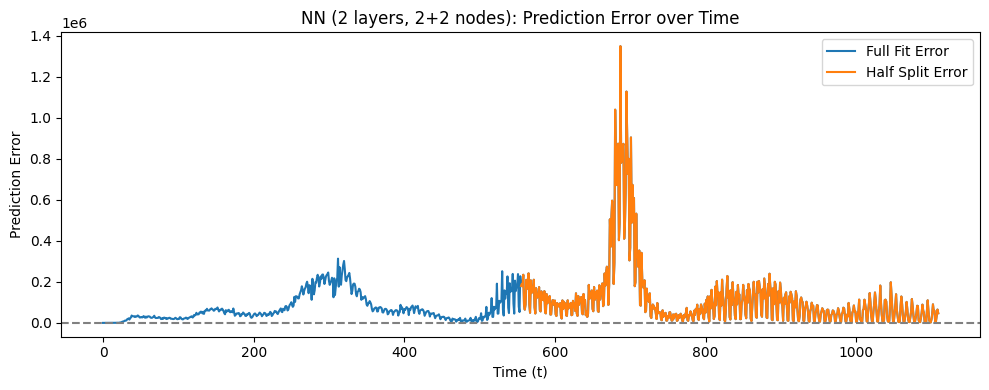

In [ ]:
#Cleaning and preparing data for the model

def preprocess_country_data(country):
    url = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/" \
          "csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
    df = pd.read_csv(url) #read in data
    df_country = df[df['Country/Region'] == country].drop(columns=['Lat', 'Long']) #filters for specific country
    df_country = df_country.groupby('Country/Region').sum().T
    df_country.columns = ['Cases']
    df_country['Daily'] = df_country['Cases'].diff()
    df_country = df_country[df_country['Daily'] > 0].dropna().reset_index(drop=True)

    #create lag features
    for i in range(1, 6):
        df_country[f'Lag_{i}'] = df_country['Daily'].shift(i)
    df_country = df_country.dropna().reset_index(drop=True)
    X = df_country[[f'Lag_{i}' for i in range(1, 6)]].astype(float).values
    y = df_country['Daily'].astype(float).values
    return X, y, df_country

# applying preprocess_country_data function to one country (US)
country = 'US'
X, y, df_country = preprocess_country_data(country)
scaler = StandardScaler() #removes mean and scaling to unit variance
X_scaled = scaler.fit_transform(X)
split_idx = len(X_scaled) // 2 #finding the middle of the data set
X_train, y_train = X_scaled[:split_idx], y[:split_idx] #split data in half into test and training set
X_test, y_test = X_scaled[split_idx:], y[split_idx:]

#Create tensors
X_tensor_all = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor_all = torch.tensor(y, dtype=torch.float32).view(-1, 1)
X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_tensor_test = torch.tensor(X_test, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# define the NN models, one for 2 neuros and one for 2 layer each gets 2
class NN_1Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 2),
            nn.ReLU(),
            nn.Linear(2, 1)
        )
    def forward(self, x):
        return self.net(x)

class NN_2Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 2),
            nn.ReLU(),
            nn.Linear(2, 2),
            nn.ReLU(),
            nn.Linear(2, 1)
        )
    def forward(self, x):
        return self.net(x)

def train_model(model, X_train, y_train, X_eval_full, y_eval_full, X_eval_half, y_eval_half, epochs=300, lr=0.01):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        y_pred_full = model(X_eval_full).numpy()
        y_pred_half = model(X_eval_half).numpy()
        mse_full = mean_squared_error(y_eval_full, y_pred_full)
        mse_half = mean_squared_error(y_eval_half, y_pred_half)
    return mse_full, mse_half

#  Linear Reg and Neural Network fits
X_sm = sm.add_constant(X_scaled)
model_lr = sm.OLS(y, X_sm).fit()
y_pred_full_lr = model_lr.predict(X_sm)
y_pred_half_lr = model_lr.predict(sm.add_constant(X_test))
mse_full_lr = mean_squared_error(y, y_pred_full_lr)
mse_half_lr = mean_squared_error(y_test, y_pred_half_lr)

model_nn1 = NN_1Layer()
mse_full_nn1, mse_half_nn1 = train_model(model_nn1, X_tensor_all, y_tensor_all, X_tensor_all, y, X_tensor_test, y_test)
model_nn2 = NN_2Layer()
mse_full_nn2, mse_half_nn2 = train_model(model_nn2, X_tensor_train, y_tensor_train, X_tensor_all, y, X_tensor_test, y_test)

# set up dataframe to compare/contrasting the different error rates
results = pd.DataFrame({
    'Model': ['Linear Regression', 'NN (1 layer, 2 nodes)', 'NN (2 layers, 2+2 nodes)'],
    'MSE (Full Fit)': [round(mse_full_lr, 2), round(mse_full_nn1, 2), round(mse_full_nn2, 2)],
    'MSE (Half Split)': [round(mse_half_lr, 2), round(mse_half_nn1, 2), round(mse_half_nn2, 2)]
})
display(results)

# graph 1 for Linear Reg
t_all = np.arange(len(y))
t_half = np.arange(len(y_test))
plt.figure(figsize=(10, 4))
plt.plot(t_all, y - y_pred_full_lr, label='Full Fit Error')
plt.plot(t_half + len(y) - len(y_test), y_test - y_pred_half_lr, label='Half Split Error')
plt.axhline(0, linestyle='--', color='gray')
plt.title('Linear Regression: Prediction Error over Time')
plt.xlabel('Time (t)')
plt.ylabel('Prediction Error')
plt.legend()
plt.tight_layout()
plt.show()

# graph 2 for 2 neuros 1 layer (Neural Network)
nn1_preds_full = model_nn1(X_tensor_all).detach().numpy().flatten()
nn1_preds_half = model_nn1(X_tensor_test).detach().numpy().flatten()
plt.figure(figsize=(10, 4))
plt.plot(t_all, y - nn1_preds_full, label='Full Fit Error')
plt.plot(t_half + len(y) - len(y_test), y_test - nn1_preds_half, label='Half Split Error')
plt.axhline(0, linestyle='--', color='gray')
plt.title('NN (1 layer, 2 nodes): Prediction Error over Time')
plt.xlabel('Time (t)')
plt.ylabel('Prediction Error')
plt.legend()
plt.tight_layout()
plt.show()

# graph for 2 layer (Neural Network)
nn2_preds_full = model_nn2(X_tensor_all).detach().numpy().flatten()
nn2_preds_half = model_nn2(X_tensor_test).detach().numpy().flatten()
plt.figure(figsize=(10, 4))
plt.plot(t_all, y - nn2_preds_full, label='Full Fit Error')
plt.plot(t_half + len(y) - len(y_test), y_test - nn2_preds_half, label='Half Split Error')
plt.axhline(0, linestyle='--', color='gray')
plt.title('NN (2 layers, 2+2 nodes): Prediction Error over Time')
plt.xlabel('Time (t)')
plt.ylabel('Prediction Error')
plt.legend()
plt.tight_layout()
plt.show()





This code forecasts daily new COVID-19 cases for the United States using time series modeling with both linear regression and two neural networks. We began by preprocessing global case data to compute daily new cases and generate lagged features from previous 5 days to use as predictors. We then split the dataset chronologically and scaled it for model efficiency. After we converted it into tensors that can be used for PyTorch. We then created two neural network architectures—a shallow model with one hidden layer and a deeper model with two hidden layers. These were trained and evaluated, alongside a linear regression baseline. Each  model was assessed using mean squared error (MSE) on both full data and a held-out test set to compare the predictive performance. Finally, prediction errors over time are visualized to highlight differences in model behavior.


Authors:
Zhenlong Zhang,
Grace Brooks,
Mingrui Xu,
Rosie Quint,
Liesel Arauz Vallecillo